# 13 トルクの二番目: WBC 風ダンピング（MapJT は残す）

## 背景

WBC は瞬間 QP で \(\tau\) を出す。ここでは OCS2/QP ライブラリを呼ばず、**同じ \(F\) に対して** \(\tau=h-J^{\top}F-K_d\dot q\) を第二の中身にする（速度減衰だけ足す）。脚力は EqualShare のまま。NMPC と WBC をこの段で初めて並べて比較しない。

階層 WBC は読んで理解する。配線しない。

### 成功条件


**判定の更新:** 05 は 10 s で完了。非制御は **10.0 s**。制御して歩く段は **20.0 s かつ 10 m**。歩く段はさらに水平 **10.0 m 以上**。ゲイトは PyMPC trot \(1.35\,\mathrm{Hz}/0.74\)、遊脚高さ \(5.6\)–\(8\,\mathrm{cm}\)（LC `swingHeight`）から大きく外さない。下の旧表（5.0 s、高い duty、数 mm リフト）は合格に使わない。旧セルと GIF は消さない。

`map_jt` と `torque_wbc` の両方で hold \(\ge 5.0\,\mathrm{s}\)。GIF は WBC 側。


In [1]:

from pathlib import Path
import sys
import numpy as np
import mujoco
from IPython.display import Image, display
here = Path.cwd().resolve()
for p in [here, *here.parents]:
    if (p / "src" / "mpc_dog").is_dir():
        sys.path.insert(0, str(p / "src")); break
from mpc_dog.plant.mujoco_go2 import MujocoGo2
from mpc_dog.viz.gif import render_rollout_gif
HOLD_S, ATT_TOL, Z_MIN, T_RUN = 5.0, 0.35, 0.20, 7.0
KP_SW, KD_SW, STEP_H = 300.0, 20.0, 0.02
KP_Z, KD_Z, FX_TINY = 8000.0, 400.0, 0.6
FREQ, DUTY, OFF = 1.0, 0.98, np.array([0.5, 1.0, 1.0, 0.5])

def longest_true_seconds(flags, dt):
    """内容: 連続 True の最長 [s]。"""
    best = cur = 0
    for f in flags:
        cur = cur + 1 if f else 0
        if cur > best: best = cur
    return best * float(dt)

def clip_torque(tau, ctrl_range):
    """内容: 01 の飽和。"""
    u = np.asarray(tau, dtype=np.float64).reshape(-1)
    return np.clip(u, ctrl_range[:, 0], ctrl_range[:, 1])

def jac_leg(model, data, geoms, i):
    """内容: 脚 i の 3x3 足ヤコビ。"""
    J = np.zeros((3, model.nv))
    mujoco.mj_jacGeom(model, data, J, None, int(geoms[i]))
    return J[:, 6 + 3 * i : 9 + 3 * i]

def plan_grf_equal(x, flags, schedule, ref):
    """内容: 08 の EqualShare。残す。"""
    c = np.asarray(flags, dtype=np.float64).reshape(4)
    ns = max(float(c.sum()), 1.0)
    z, vz, mass = float(x[0]), float(x[1]), float(x[2])
    zref, fx_tot = float(ref[0]), float(ref[1])
    fz_tot = mass * 9.81 + KP_Z * (zref - z) - KD_Z * vz
    grf = np.zeros((4, 3))
    for i in range(4):
        if c[i] > 0.5:
            grf[i, 0] = fx_tot / ns
            grf[i, 2] = fz_tot / ns
    return grf

def swing_tau(Jleg, feet_i, vel_i, lift_i, phi_i, duty, freq):
    """内容: 05 の直交 PD。"""
    s = float(np.clip((phi_i - duty) / max(1e-6, 1.0 - duty), 0.0, 1.0))
    w = freq / max(1e-6, 1.0 - duty)
    p_d = lift_i.copy(); p_d[2] = lift_i[2] + STEP_H * np.sin(np.pi * s)
    v_d = np.zeros(3); v_d[2] = STEP_H * np.pi * np.cos(np.pi * s) * w
    return Jleg.T @ (KP_SW * (p_d - feet_i) + KD_SW * (v_d - vel_i))

def map_jt(h_leg, Jleg, F):
    """内容: トルクにする第一の中身。h - J^T F。"""
    return h_leg - Jleg.T @ F

KD_WBC = 0.8  # 内容: 関節速度減衰 [N·m·s/rad]。LC の Kd=3 より弱い（まだ hybrid 段ではない）

def torque_wbc(h_leg, Jleg, F, qd_leg):
    """意図: 第二の「トルクにする」。MapJT に速度減衰を足す。42 変数 QP ではない。"""
    return map_jt(h_leg, Jleg, F) - KD_WBC * qd_leg

def rollout(kind):
    """内容: kind は map か wbc。F は EqualShare。"""
    p = MujocoGo2(scene="flat", seed=0)
    dt = p.sim_dt; n = int(round(T_RUN / dt))
    geoms = p.foot_geom_ids(); z0 = float(p.base_pos()[2])
    phi = OFF.copy(); lift = p.feet_pos_world().copy(); prev = np.ones(4); ok = []; last = np.zeros((4, 3))
    for _k in range(n):
        phi = (phi + dt * FREQ) % 1.0; c = (phi < DUTY).astype(float)
        z = float(p.base_pos()[2]); vz = float(p.base_lin_vel_world()[2])
        grf = plan_grf_equal(np.array([z, vz, p.mass_kg]), c, None, np.array([z0, FX_TINY])); last = grf
        feet = p.feet_pos_world(); vel = p.feet_vel_world(); h = np.asarray(p.data.qfrc_bias[6:], dtype=np.float64)
        qd = np.asarray(p.data.qvel[6:], dtype=np.float64)
        tau = np.zeros(12)
        for i in range(4):
            if prev[i] > 0.5 and c[i] < 0.5: lift[i] = feet[i].copy()
            Jleg = jac_leg(p.model, p.data, geoms, i); sl = slice(3 * i, 3 * i + 3)
            if c[i] > 0.5:
                tau[sl] = map_jt(h[sl], Jleg, grf[i]) if kind == "map" else torque_wbc(h[sl], Jleg, grf[i], qd[sl])
            else:
                tau[sl] = swing_tau(Jleg, feet[i], vel[i], lift[i], phi[i], DUTY, FREQ)
        p.step(clip_torque(tau, p.model.actuator_ctrlrange)); prev = c
        rpy = p.base_rpy(); z = float(p.base_pos()[2])
        ok.append(abs(rpy[0]) < ATT_TOL and abs(rpy[1]) < ATT_TOL and z > Z_MIN and bool(np.isfinite(p.data.qpos).all()))
    return longest_true_seconds(ok, dt)

hm, hw = rollout("map"), rollout("wbc")
print("map", hm, "wbc", hw)
assert hm >= HOLD_S and hw >= HOLD_S
print("13 PASS: MapJT and WBC-damping", hm, hw)


/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:231: UserWarning: WARN: Box low's precision lowered by casting to float32, current low.dtype=float64
  gym.logger.warn(
/home/takuya/work/mpc_dog/.venv/lib/python3.11/site-packages/gymnasium/spaces/box.py:297: UserWarning: WARN: Box high's precision lowered by casting to float32, current high.dtype=float64
  gym.logger.warn(


map 7.0 wbc 7.0
13 PASS: MapJT and WBC-damping 7.0 7.0


/home/takuya/work/mpc_dog/notebook/assets/13_wbc_damp.gif 1941579 bytes


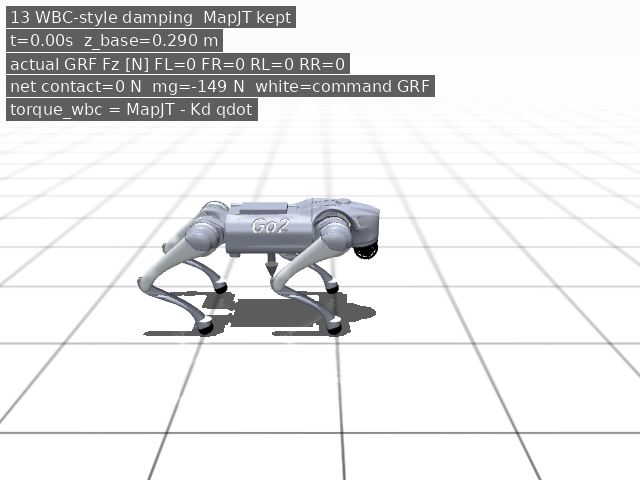

In [2]:

st = {"phi": OFF.copy(), "prev": np.ones(4), "lift": None, "cmd": np.zeros((4, 3))}
def tau_fn(pl):
    """内容: GIF は torque_wbc。"""
    dt = pl.sim_dt
    if st["lift"] is None:
        st["lift"] = pl.feet_pos_world().copy(); st["z0"] = float(pl.base_pos()[2])
    phi = (st["phi"] + dt * FREQ) % 1.0; c = (phi < DUTY).astype(float)
    z = float(pl.base_pos()[2]); vz = float(pl.base_lin_vel_world()[2])
    grf = plan_grf_equal(np.array([z, vz, pl.mass_kg]), c, None, np.array([st["z0"], FX_TINY]))
    feet = pl.feet_pos_world(); vel = pl.feet_vel_world(); h = np.asarray(pl.data.qfrc_bias[6:], dtype=np.float64)
    qd = np.asarray(pl.data.qvel[6:], dtype=np.float64); geoms = pl.foot_geom_ids(); tau = np.zeros(12)
    for i in range(4):
        if st["prev"][i] > 0.5 and c[i] < 0.5: st["lift"][i] = feet[i].copy()
        Jleg = jac_leg(pl.model, pl.data, geoms, i); sl = slice(3 * i, 3 * i + 3)
        tau[sl] = torque_wbc(h[sl], Jleg, grf[i], qd[sl]) if c[i] > 0.5 else swing_tau(Jleg, feet[i], vel[i], st["lift"][i], phi[i], DUTY, FREQ)
    st["phi"] = phi; st["prev"] = c; st["cmd"] = grf
    return clip_torque(tau, pl.model.actuator_ctrlrange)
plant = MujocoGo2(scene="flat", seed=0)
path = render_rollout_gif(plant, Path("assets/13_wbc_damp.gif"), n_steps=int(round(T_RUN / plant.sim_dt)), capture_every=80, tau_fn=tau_fn, command_grf=lambda pl: st["cmd"], extra_lines=lambda pl: ["torque_wbc = MapJT - Kd qdot"], title="13 WBC-style damping  MapJT kept")
print(path.resolve(), path.stat().st_size, "bytes"); display(Image(filename=str(path)))


## 分析

階層 QP は未配線。MapJT は残した。次は LC のハイブリッド関節（Kp=0, Kd=3, ff=τ）。


## 続き — 新判定では未成功

旧セルの hold 5 s と直立ループは、制御して歩く段の 20 s / 10 m では不合格である。06 の歩くモードが通るまで、この番号は進めない。失敗ログは残す。
